In [1]:
%matplotlib widget
import numpy as np
import scipp as sc
import tof
from trex.instrument import Instrument
from trex.components.source import Source


central_wavelength = 1.5 * sc.Unit("Å")
mode = "High Resolution"  # Chopper mode
rrm = 12
T_OFFSET = sc.scalar(1.7, unit="ms")

trex = Instrument(central_wavelength, rrm, mode, T_OFFSET)
trex.source = Source(facility="ess", neutrons=10_000_000, pulses=1)
res_no_sample = trex.model.run()

In [12]:
# define an inelastic sample
rng = np.random.default_rng(seed=42)


def uniform_delta_e(e_i):
    # Uniform sampling between -20 and 0 meV
    de = sc.array(dims=e_i.dims, values=rng.uniform(-40, 0, size=e_i.shape), unit="meV")
    return e_i.to(unit="meV", copy=False) - de


trex.sample = tof.InelasticSample(
    distance=trex.monitors["Monitor at Sample"].distance,
    name="sample",
    func=uniform_delta_e,
)  # type: ignore
res = trex.model.run()

/var/folders/s5/6527bxpx7xnbbzxz94s_d2xm0000gp/T/ipykernel_8518/2012936398.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


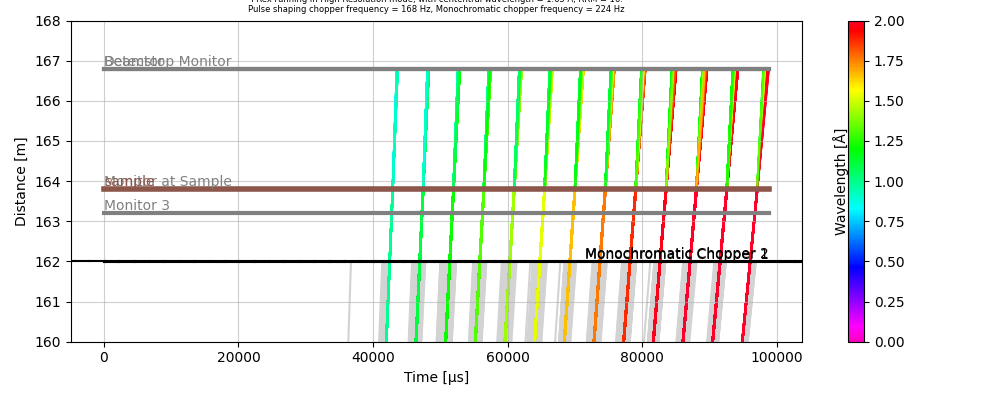

In [17]:
%matplotlib widget
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

res.plot(visible_rays=5_000_000, blocked_rays=50_000, ax=ax, vmin=0.0, vmax=2)
# ax.set_xlim([30_000, 100_000])
ax.set_ylim([160, 168])
ax.set_title(str(trex), fontsize=6)
ax.grid(alpha=0.6)
fig.tight_layout()

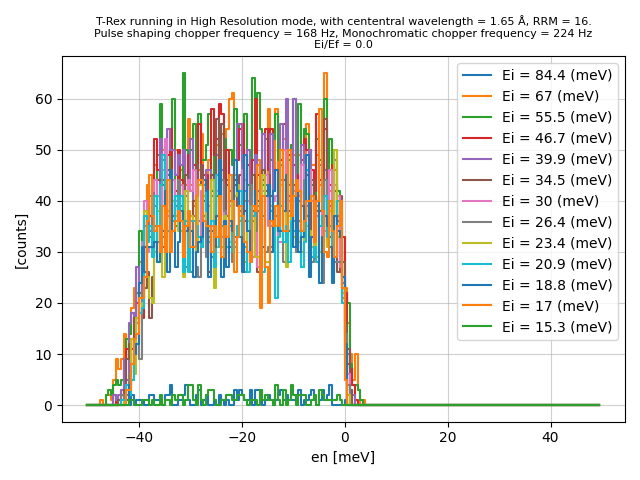

In [18]:
import plopp as pp

ei_ef_ratio = 0.0
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 50, 0.5, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)
fig.tight_layout()

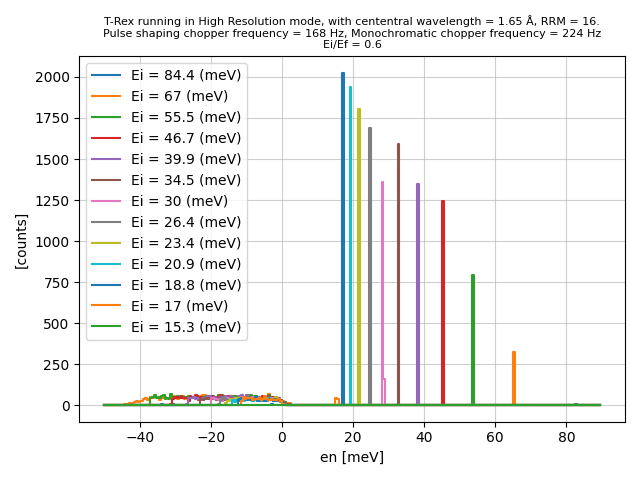

In [19]:
import plopp as pp

ei_ef_ratio = 0.6
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 90, 0.5, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)

fig.tight_layout()

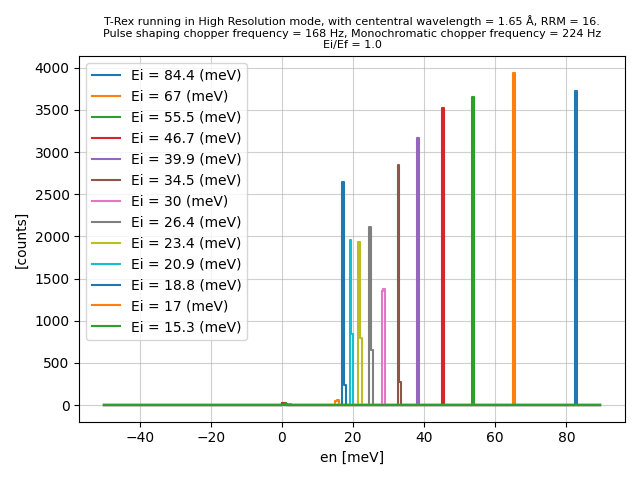

In [20]:
import plopp as pp

ei_ef_ratio = 1.0
params = trex.unwrap_frame(res_no_sample, ei_ef_ratio=ei_ef_ratio)
reduced_list = trex.toa_to_energy(res, *params)
hist_dict = {
    f"Ei = {reduced.coords['ei'].values:.3g} (meV)": reduced.hist(
        en=sc.arange("en", -50, 90, 0.5, unit="meV")
    )
    for reduced in reduced_list
}

fig, ax = plt.subplots()
p = pp.plot(hist_dict, markersize=4, ax=ax)
ax.set_title(str(trex) + f"\nEi/Ef = {ei_ef_ratio}", fontsize=8)
ax.grid(alpha=0.6)

fig.tight_layout()